# 15 — Drop-off by section

Among clients who started the first-visit form (`reasons_completed = 1`), the completion rate of every later section — the lowest number is the biggest drop-off point. Mirrors `docs/clientQueries.md` §3.2.

In [ ]:
import pandas as pd
from db import get_engine

engine = get_engine()

In [2]:
query = """
SELECT
  ROUND(100 * AVG(food_preferences_completed), 1)        AS pct_food_preferences,
  ROUND(100 * AVG(family_history_completed), 1)          AS pct_family_history,
  ROUND(100 * AVG(weight_history_completed), 1)          AS pct_weight_history,
  ROUND(100 * AVG(cardio_pathology_completed), 1)        AS pct_cardio_pathology,
  ROUND(100 * AVG(metabolic_pathology_completed), 1)     AS pct_metabolic_pathology,
  ROUND(100 * AVG(neurological_pathology_completed), 1) AS pct_neurological_pathology,
  ROUND(100 * AVG(gastro_pathology_completed), 1)        AS pct_gastro_pathology,
  ROUND(100 * AVG(hepatic_pathology_completed), 1)       AS pct_hepatic_pathology,
  ROUND(100 * AVG(dermatologic_pathology_completed), 1) AS pct_dermatologic_pathology,
  ROUND(100 * AVG(thyroid_pathology_completed), 1)       AS pct_thyroid_pathology,
  ROUND(100 * AVG(respiratory_pathology_completed), 1)  AS pct_respiratory_pathology,
  ROUND(100 * AVG(life_style_completed), 1)              AS pct_life_style,
  ROUND(100 * AVG(medical_values_completed), 1)          AS pct_medical_values
FROM visits
WHERE visit_type = '1' AND reasons_completed = 1;
"""

df = pd.read_sql(query, engine)
print(df)

   pct_food_preferences  pct_family_history  pct_weight_history  \
0                  98.0               100.0                98.0   

   pct_cardio_pathology  pct_metabolic_pathology  pct_neurological_pathology  \
0                  98.0                     98.0                        98.0   

   pct_gastro_pathology  pct_hepatic_pathology  pct_dermatologic_pathology  \
0                  98.0                   98.0                        98.0   

   pct_thyroid_pathology  pct_respiratory_pathology  pct_life_style  \
0                   98.0                       95.9            95.9   

   pct_medical_values  
0                91.8  


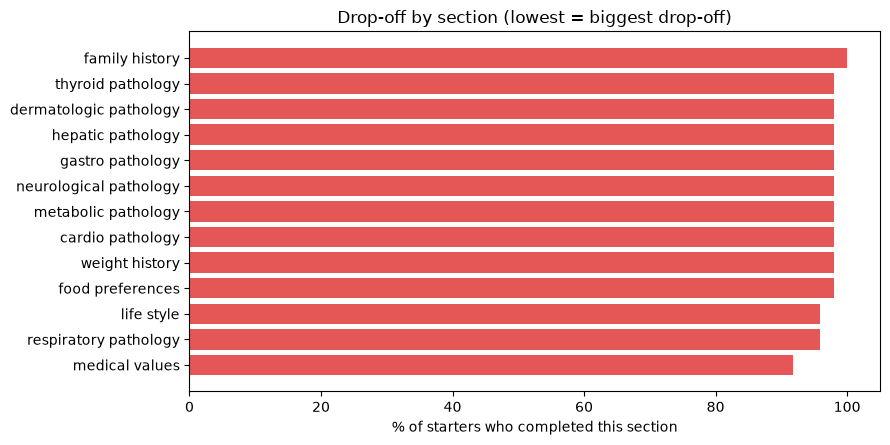

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

dropoff = (
    df.melt(var_name="section", value_name="pct_complete")
    .assign(section=lambda d: d["section"].str.removeprefix("pct_").str.replace("_", " "))
    .sort_values("pct_complete")
)

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(dropoff))))
ax.barh(dropoff["section"], dropoff["pct_complete"], color="#E45756")
ax.set_xlabel("% of starters who completed this section")
ax.set_title("Drop-off by section (lowest = biggest drop-off)")
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/dropoff_by_section.png", dpi=150)
plt.show()